# Import Libraries

In [1]:
import pandas as pd
import numpy as np

# Read the processed India crop yield data

In [2]:

data = pd.read_csv('/content/Processed_India_Crop_Yield_Data.csv')

# Display basic info
print(data.info())
print(data.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4048 entries, 0 to 4047
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     4048 non-null   int64  
 1   Area                           4048 non-null   object 
 2   Item                           4048 non-null   object 
 3   Year                           4048 non-null   int64  
 4   hg/ha_yield                    4048 non-null   int64  
 5   average_rain_fall_mm_per_year  4048 non-null   float64
 6   pesticides_tonnes              4048 non-null   float64
 7   avg_temp                       4048 non-null   float64
dtypes: float64(3), int64(3), object(2)
memory usage: 253.1+ KB
None
   Unnamed: 0   Area     Item  Year  hg/ha_yield  \
0       10502  India  Cassava  1990       205381   
1       10503  India  Cassava  1990       205381   
2       10504  India  Cassava  1990       205381   
3       10505  In

# Feature Engineering for Temperate - Rainfall Interaction

In [3]:
data['temp_rainfall_interaction'] = data['avg_temp'] * data['average_rain_fall_mm_per_year']

# Avg Rainfall in mm per year

In [4]:
mean_rainfall = data['average_rain_fall_mm_per_year'].mean()

# Create deviation feature
data['rainfall_deviation'] = data['average_rain_fall_mm_per_year'] - mean_rainfall

# Rainfall Squared

In [5]:
data['rainfall_squared'] = data['average_rain_fall_mm_per_year'] ** 2

# Temperature Sqaured

In [6]:
data['temp_squared'] = data['avg_temp'] ** 2

# Pesticides Per Rainfall

In [7]:
data['pesticide_per_rainfall'] = data['pesticides_tonnes'] / (data['average_rain_fall_mm_per_year'] + 1)

In [8]:
# Ensure year is numeric
data['Year'] = pd.to_numeric(data['Year'], errors='coerce')

# Newly engineered features preview

In [9]:
print("Newly engineered features preview:")
print(data[['temp_rainfall_interaction', 'rainfall_deviation', 'rainfall_squared', 'temp_squared', 'pesticide_per_rainfall']].head())


Newly engineered features preview:
   temp_rainfall_interaction  rainfall_deviation  rainfall_squared  \
0                   27703.14                 0.0         1172889.0   
1                   29111.04                 0.0         1172889.0   
2                   27930.57                 0.0         1172889.0   
3                   26100.30                 0.0         1172889.0   
4                   27345.75                 0.0         1172889.0   

   temp_squared  pesticide_per_rainfall  
0      654.3364               69.188192  
1      722.5344               69.188192  
2      665.1241               69.188192  
3      580.8100               69.188192  
4      637.5625               69.188192  


In [10]:
# Save for your model training pipeline
data.to_csv('Feature_Engineered_Crop_Yield_Data.csv', index=False)

print("✅ Feature engineered dataset saved as 'Feature_Engineered_Crop_Yield_Data.csv'")

✅ Feature engineered dataset saved as 'Feature_Engineered_Crop_Yield_Data.csv'


# Define new feature set for model

In [13]:

X = data[['average_rain_fall_mm_per_year', 'avg_temp', 'pesticides_tonnes',
          'temp_rainfall_interaction', 'rainfall_deviation', 'rainfall_squared',
          'temp_squared', 'pesticide_per_rainfall']]

y = data['hg/ha_yield']

# Libraries

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Define features and target

In [16]:
# Load your feature engineered dataset
data = pd.read_csv('Feature_Engineered_Crop_Yield_Data.csv')

X = data[['average_rain_fall_mm_per_year', 'avg_temp', 'pesticides_tonnes',
          'temp_rainfall_interaction', 'rainfall_deviation', 'rainfall_squared',
          'temp_squared', 'pesticide_per_rainfall']]

y = data['hg/ha_yield']

# Initialize and train model

In [17]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

# Extracting feature importances

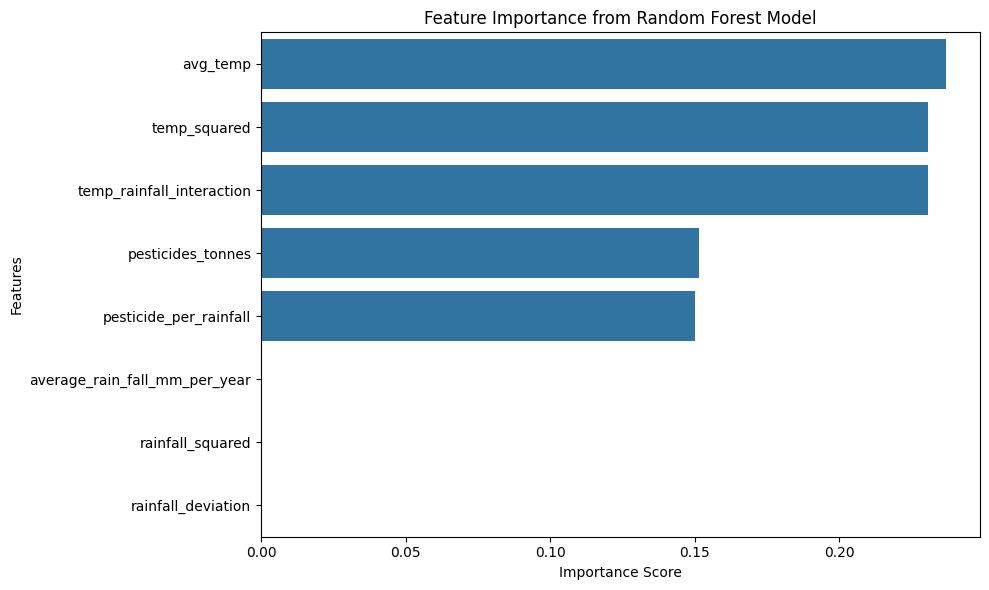

In [18]:

importances = rf_model.feature_importances_

# Create a dataframe for plotting
feat_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

# Sort by importance
feat_importance_df.sort_values(by='Importance', ascending=False, inplace=True)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feat_importance_df)
plt.title('Feature Importance from Random Forest Model')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()